# EDA means data ko samajhna detail me  and Explain krna 

In [1]:
import pandas as pd 

import numpy as np 

import seaborn as sns

import matplotlib.pyplot as plt 



## Exporting the file 

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


## seeing the informations of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Finding if there is any values

In [4]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## checking if there is any duplicates in a dataset

In [5]:
df.duplicated().sum()

np.int64(0)

## How our dataset Looks Mathematically

In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Correlation btw the Numerical values in a Dataset

In [7]:
df.corr(numeric_only = True)

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


# Checking data types of each Columns

In [8]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

# How many rows and columns our dataset contains ? 

In [9]:
df.shape

(1000, 8)

## column names of the dataset

In [10]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# Comparing average score of both genders in Reading 

In [11]:
mean_scores = df.groupby('gender')['reading score'].mean()
print(mean_scores)

gender
female    72.608108
male      65.473029
Name: reading score, dtype: float64


# Comparing average score of both genders in Writing 

In [12]:
mean_score_writing = df.groupby("gender")['writing score'].mean()

mean_score_writing


gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64

# Comparing average score of both genders in Maths

In [13]:
mean_score_math = df.groupby("gender")['math score'].mean()

mean_score_math


gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

# calculating difference btw male and female mean score

In [14]:
diff = mean_scores['female'] - mean_scores['male']
print(diff)

7.135079062464953


# calculationg how much females are doing better than males 

In [15]:
percent = (diff / mean_scores['male']) * 100
print(percent)

# females ra edoing 10% better than males in average 

10.897737841777385


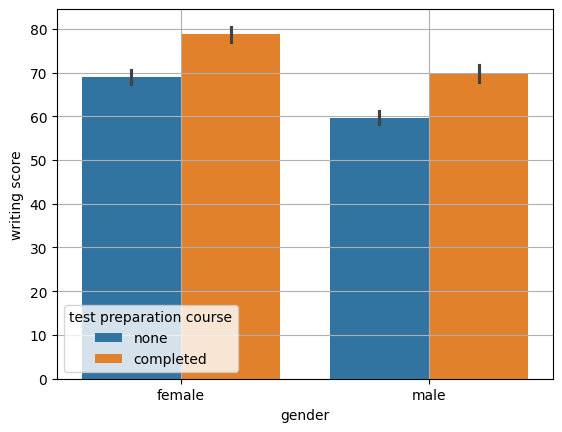

In [16]:
sns.barplot(df, x = "gender" , y = "writing score" , hue = "test preparation course")

plt.grid()

# in writting Score 

## females are doing better than males in writting score 

## females who completed tpc are doing better than females who are none.

## males are doing better than males in writting score 

## males who completed tpc are doing better than males who are none.


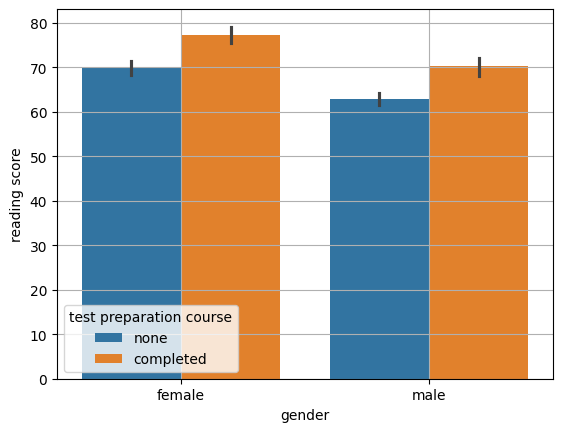

In [17]:
sns.barplot(df, x = "gender" , y = "reading score" , hue = "test preparation course")

plt.grid()

# in reading  Score 

## females are doing better than males  

## females who completed tpc are doing better than females who are none.

## males are doing better than males in writting score 

## males who completed tpc are doing better than males who are none.


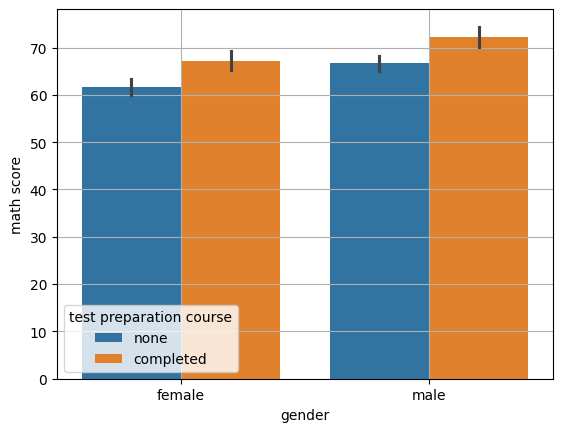

In [18]:




sns.barplot(df, x = "gender" , y = "math score" , hue = "test preparation course")

plt.grid()


# In math score 

## females who complte tpc have higher than male none but if we comare both;s none value than males have upper hand 

## males who completed tpc are higher than females who completed tpc and higher than males who are none . 

## females have high math score than female who are didnt prepare for the test(none). 




In [19]:
g = df.groupby("gender")[["math score" , "writing score" , "reading score"]].mean()
g

,math score,writing score,reading score
gender,,,
female,63.633205,72.467181,72.608108
male,68.728216,63.311203,65.473029


# calculating how much females are doing better than males in different categories

In [20]:

female = g.loc['female']  #female wali row uthao”
male = g.loc['male']      # male  wali row uthao”

percent = (female - male) / male * 100
print(percent)  # male se -7% niche hai females 

math score       -7.413274
writing score    14.461861
reading score    10.897738
dtype: float64


# Adding a new column with the name of Total_score

In [21]:
df["Total_score"] =df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218
1,female,group C,some college,standard,completed,69,90,88,247,247
2,female,group B,master's degree,standard,none,90,95,93,278,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148
4,male,group C,some college,standard,none,76,78,75,229,229


## Calculating how much females are doing better than males on avergae in Total score

In [22]:
g = df.groupby('gender')['total_score'].mean()

In [23]:
female = g['female']
male = g['male']

percent = (female - male) / male * 100
print(percent)   



5.668526810111455


## Adding a new column with the name of Average score  so we can perform EDA on that 

In [24]:
df["Average_score"]  = (df["math score"]+df["reading score"]+df["writing score"]) / 3

<Axes: xlabel='gender', ylabel='Average_score'>

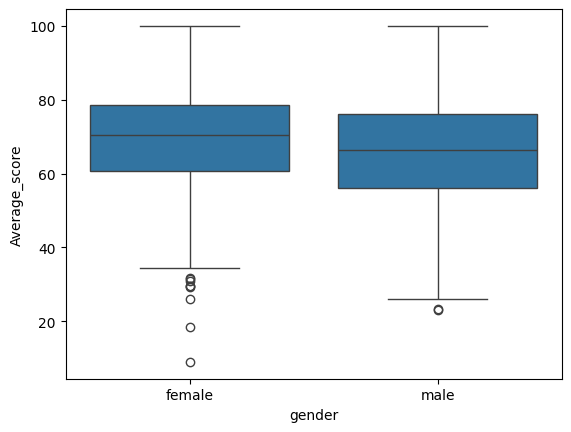

In [25]:
sns.boxplot(x='gender', y='Average_score', data=df)

<Axes: xlabel='gender', ylabel='Average_score'>

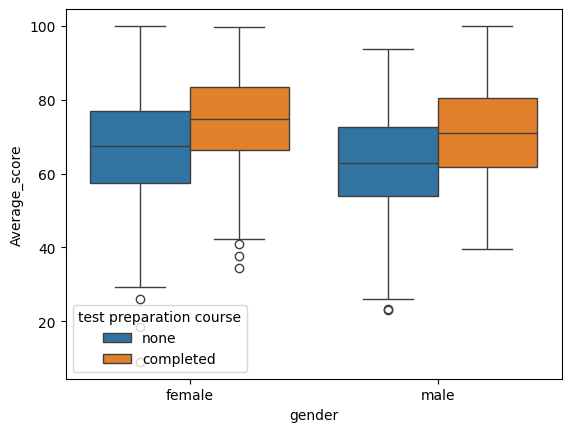

In [26]:
sns.boxplot(x='gender', y='Average_score', hue='test preparation course', data=df)

<Axes: xlabel='Average_score', ylabel='Count'>

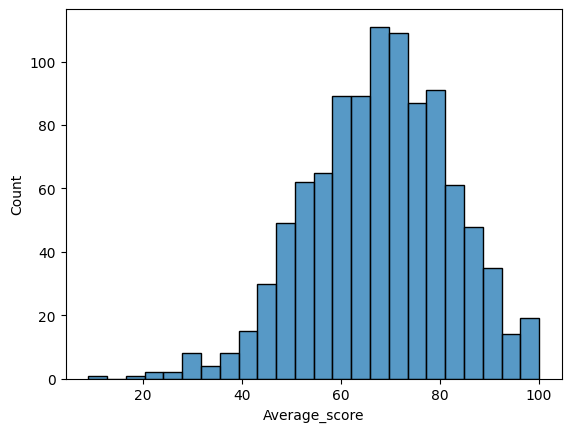

In [27]:

sns.histplot(df['Average_score'])

# Adding a new column with the name of Performance and divided it into  different Cateogires 

In [28]:
df["performance"] = df["Average_score"].apply(
    lambda x:"High" if x>75 else "Medium" if x>50 else "Low"
)

In [29]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,total_score,Average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218,72.666667,Medium
1,female,group C,some college,standard,completed,69,90,88,247,247,82.333333,High
2,female,group B,master's degree,standard,none,90,95,93,278,278,92.666667,High
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,229,229,76.333333,High


<Axes: xlabel='performance', ylabel='count'>

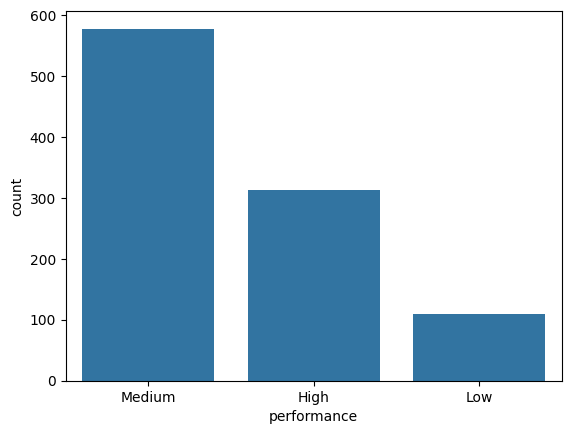

In [30]:
sns.countplot(df,x="performance")

In [31]:
# Most students are falling under the medium count. 

<Axes: xlabel='performance', ylabel='count'>

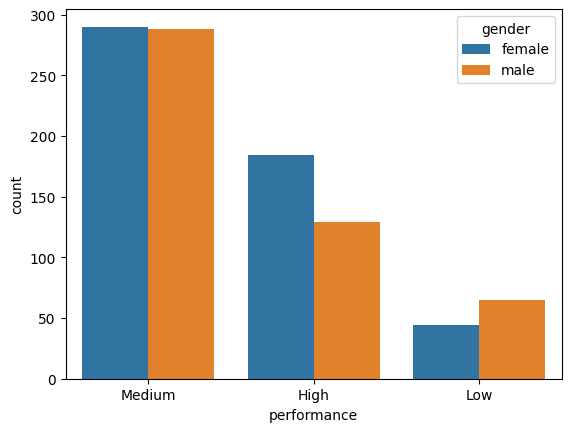

In [32]:
sns.countplot(df,x="performance",hue="gender")

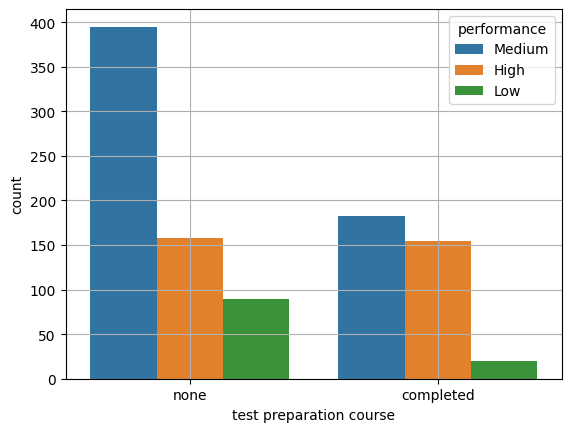

In [33]:
sns.countplot(df , x = "test preparation course" , hue = "performance")

plt.grid()

## Comparing on the basis of Performance the both genders.

In [34]:
pd.crosstab(df["performance"], df["gender"], normalize = "columns") *100

gender,female,male
performance,,
High,35.521236,26.763485
Low,8.494208,13.485477
Medium,55.984556,59.751037


In [35]:
pd.crosstab(df["performance"] , df["test preparation course"] , normalize = "columns")*100

test preparation course,completed,none
performance,,
High,43.296089,24.610592
Low,5.586592,13.862928
Medium,51.117318,61.526480


# Lets see the relations between race and parental lvl of education

In [38]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,total_score,Average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218,72.666667,Medium
1,female,group C,some college,standard,completed,69,90,88,247,247,82.333333,High
2,female,group B,master's degree,standard,none,90,95,93,278,278,92.666667,High
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,229,229,76.333333,High


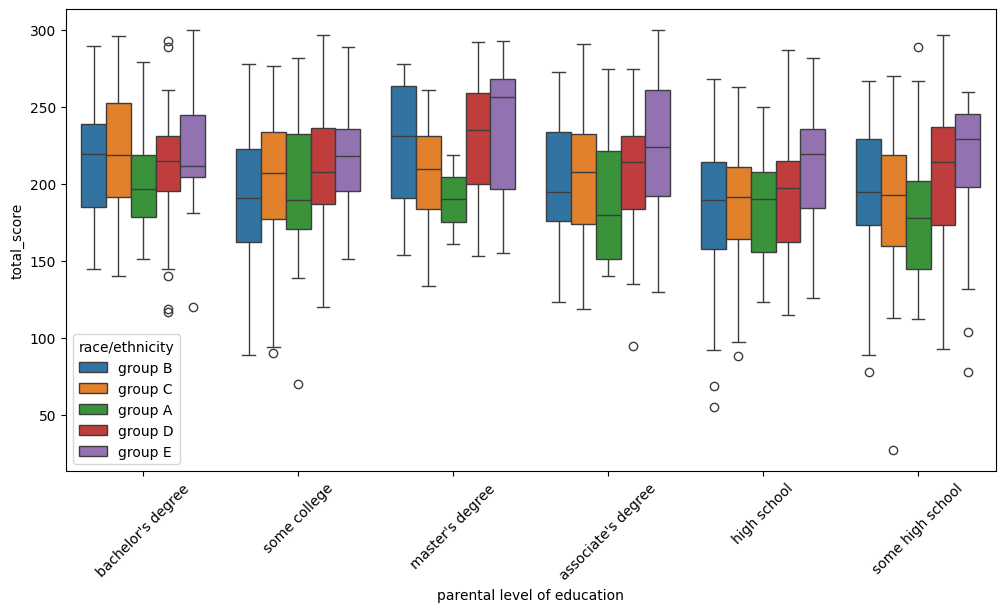

In [49]:
plt.figure(figsize=(12,6))

sns.boxplot(df , x = "parental level of education" , y = "total_score" , hue = "race/ethnicity")  
plt.xticks(rotation=45)
plt.show()


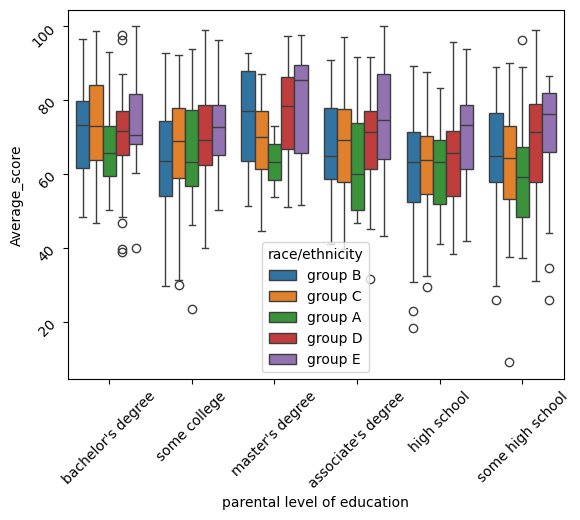

In [58]:
sns.boxplot(df, x='parental level of education', y='Average_score',hue='race/ethnicity',)

plt.xticks(rotation = 45)  # taakin chipke nhi text ek dusre se 

plt.yticks(rotation = 45)

plt.show()

<Axes: xlabel='gender', ylabel='Average_score'>

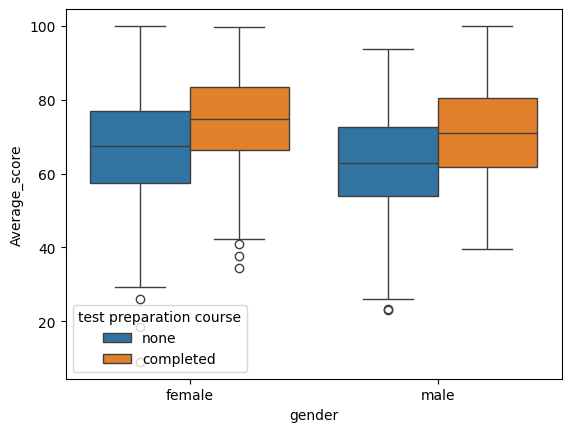

In [61]:
sns.boxplot(df, x = "gender" , y = "Average_score"  , hue = 'test preparation course')

In [64]:
pd.crosstab(df["performance"],df["gender"], normalize = "columns")*100

gender,female,male
performance,,
High,35.521236,26.763485
Low,8.494208,13.485477
Medium,55.984556,59.751037


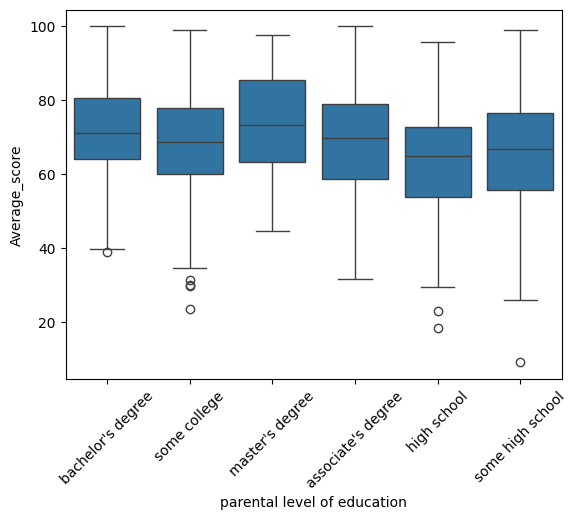

In [69]:

sns.boxplot(df,x = "parental level of education" , y = "Average_score")

plt.xticks(rotation = 45)

plt.show()

In [70]:
pd.crosstab(df['performance'], df['parental level of education'], normalize='columns') * 100

parental level of education,associate's degree,bachelor's degree,high school,master's degree,some college,some high school
performance,,,,,,
High,36.486486,36.440678,18.877551,47.457627,32.743363,27.932961
Low,8.558559,7.627119,17.346939,1.694915,6.637168,17.318436
Medium,54.954955,55.932203,63.775510,50.847458,60.619469,54.748603


<Figure size 5000x5000 with 0 Axes>

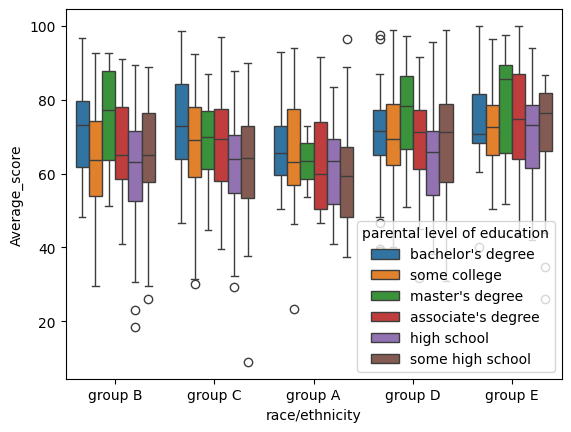

<Figure size 5000x5000 with 0 Axes>

In [75]:
sns.boxplot(
    x='race/ethnicity',
    y='Average_score',
    hue='parental level of education',
    data=df
)

plt.figure(figsize=(50,50))
